# Adversarial Evasion: Spam Email Classifier

This notebook tells the story of how a TF-IDF + Logistic Regression spam classifier can be fooled by three simple text-manipulation attacks. All attack and evaluation logic is imported directly from `train.py`, `attack.py`, and `evaluate.py` — this notebook adds **no duplicate logic**, only exploration and visualization.

**Dataset:** Spam Email Classification Dataset by purusinghvi (Kaggle) — 83,446 emails  
**Model:** Logistic Regression on TF-IDF features (~95–98% baseline accuracy)  
**Attacks:** Character Obfuscation · Synonym Substitution · Ham Word Injection

In [2]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Path setup ────────────────────────────────────────────────────────────────
# This notebook lives in notebooks/; the lab scripts live one level up.
# We add that parent directory to Python's search path so imports work.
# Crucially, Path(__file__).parent inside each lab script still resolves
# to *its own* directory, so all internal paths (model.pkl, etc.) stay correct.
lab_dir = Path('..').resolve()
if str(lab_dir) not in sys.path:
    sys.path.insert(0, str(lab_dir))

# ── Import from existing lab scripts (no logic duplicated here) ───────────────
from attack import ATTACKS, ATTACK_NAMES, load_top_spam_words
from evaluate import _load_artifacts, _predict, _run_attack

# ── Visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('Imports OK.')
print('Lab directory:', lab_dir)

Imports OK.
Lab directory: C:\Users\Hasina Rindra\adversarial-ml\evasion\email-spam-evasion


---
## Section 1 — The Data

We load `data/emails.csv` — the Spam Email Classification Dataset (83,446 emails).  
Two columns: `label` (integer 0/1) and `text` (raw email body).

The integer labels are mapped to readable strings (`0 → ham`, `1 → spam`) to match the preprocessing done in `train.py`.

In [3]:
# Load emails.csv — one level up from this notebooks/ folder
data_path = Path('..') / 'data' / 'emails.csv'
df = pd.read_csv(data_path)

# Map integer labels to strings — mirrors train.py's preprocessing step
df['label'] = df['label'].map({0: 'ham', 1: 'spam'})

counts = df['label'].value_counts()

print(f'Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns : {list(df.columns)}')
print()
print('Class distribution:')
for label, n in counts.items():
    print(f'  {label:<6}  {n:>7,}  ({n / len(df):.1%})')

Shape   : 83,448 rows x 2 columns
Columns : ['label', 'text']

Class distribution:
  spam     43,910  (52.6%)
  ham      39,538  (47.4%)


In [5]:
# Show 2 real ham and 2 real spam examples from the dataset.
# chr(10) is the newline character — used here to avoid a backslash
# inside a string literal, which would need extra escaping.
sep = '=' * 62
for label in ['ham', 'spam']:
    print()
    print(sep)
    print(f'  {label.upper()} EXAMPLES')
    print(sep)
    samples = df[df['label'] == label]['text'].dropna().sample(2, random_state=7)
    for i, text in enumerate(samples, 1):
        # Truncate to 300 chars and collapse newlines for compact display
        preview = str(text)[:300].replace(chr(10), ' ')
        print()
        print(f'  [{i}] {preview} ...')


  HAM EXAMPLES

  [1] the sample function has a prob argument that determines the probabilities of each element being sampled put your proportion of women in there and see if that works for you gregory greg l snow ph d statistical data center intermountain healthcare greg snow intermountainmail org escapenumber escapenum ...

  [2] the following contracts were truly negotiated as one - part rates ( inclusive of reservation , commodity and surcharges ) : k # 24194 pnm $ 0 . 1100 / dth k # 24568 enervest $ 0 . 2200 / dth k # 24654 ena $ 0 . 2175 / dth the way the invoice system is designed , all contracts identified as one - par ...

  SPAM EXAMPLES

  [1] timepieces by rolex fri escapenumber jun escapenumber escapenumber escapenumber escapenumber escapenumber impress your friends and co workers rolex cartier breitling omega frank muller patek philippe and many more own one today and look great for cheap http lomrwoizw admirrante com marlon corona in  ...

  [2] take advantage of mycana

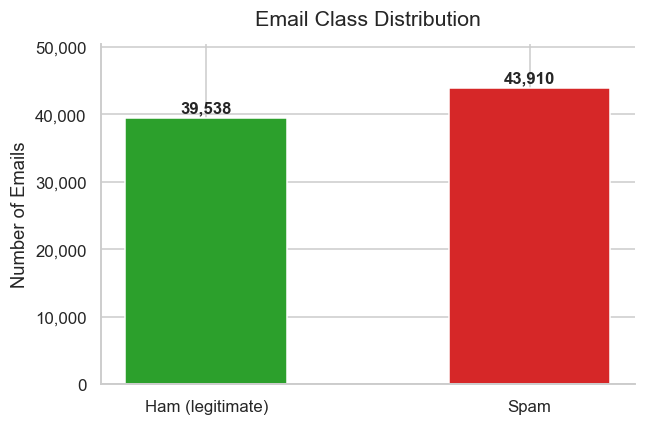

In [4]:
# Bar chart: how many ham vs spam emails are in the dataset?
fig, ax = plt.subplots(figsize=(6, 4))

labels  = ['Ham (legitimate)', 'Spam']
values  = [counts.get('ham', 0), counts.get('spam', 0)]
palette = ['#2ca02c', '#d62728']   # green = ham, red = spam

bars = ax.bar(labels, values, color=palette, width=0.5, edgecolor='white')

# Annotate each bar with its exact count
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold'
    )

ax.set_title('Email Class Distribution', fontsize=14, pad=12)
ax.set_ylabel('Number of Emails')
ax.set_ylim(0, max(values) * 1.15)
# Format y-axis tick labels with commas (e.g. 50,000 not 50000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

---
## Section 2 — The Victim Model

After running `python train.py`, the Logistic Regression model assigns a **coefficient** to every word in the TF-IDF vocabulary:

- **Positive coefficient** → the word pushes predictions toward *spam*
- **Negative coefficient** → the word pushes predictions toward *ham*

The chart below shows the 15 words with the **highest positive coefficients** — the features the model relies on most to flag spam.  
**These are the targets of our attacks.**

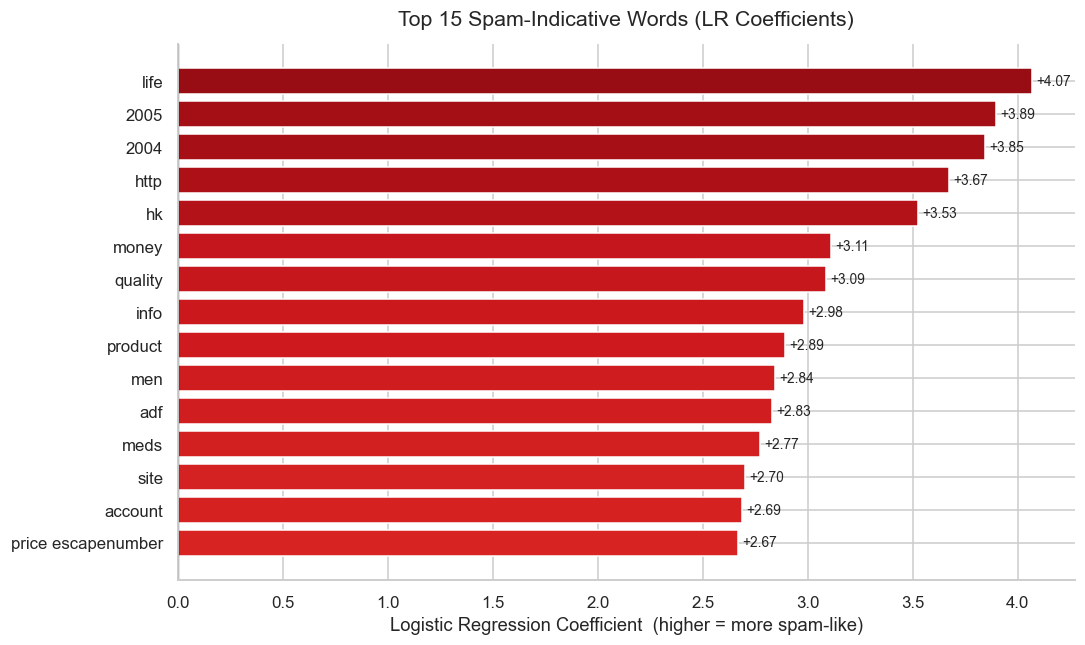

In [6]:
# Load the word list and LR coefficients saved by train.py.
# We load the JSON directly (not via load_top_spam_words()) because we
# need both words AND their scores, and load_top_spam_words() returns only words.
words_json_path = Path('..') / 'top_spam_words.json'
with open(words_json_path, encoding='utf-8') as f:
    words_data = json.load(f)

# Reverse so the highest-coefficient word appears at the TOP of the chart
top_words  = words_data['top_spam_words'][:15][::-1]
top_scores = words_data['top_spam_scores'][:15][::-1]

# Shade bars by coefficient: stronger red = higher spam weight
max_score = max(top_scores)
colors = [plt.cm.Reds(0.35 + 0.55 * (s / max_score)) for s in top_scores]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_words, top_scores, color=colors, edgecolor='white')

# Annotate each bar with its coefficient value
for bar, score in zip(bars, top_scores):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{score:+.2f}',
        va='center', fontsize=9
    )

ax.set_title('Top 15 Spam-Indicative Words (LR Coefficients)', fontsize=14, pad=12)
ax.set_xlabel('Logistic Regression Coefficient  (higher = more spam-like)')
ax.axvline(0, color='black', linewidth=0.8)
sns.despine()
plt.tight_layout()
plt.show()

The bars above are our **attack surface**. Each word shown is a token that the TF-IDF vectorizer recognises and assigns strong positive weight to.  

Because TF-IDF only understands *exact tokens*, modifying even one character of these words — or replacing them with a synonym — strips their contribution to the spam score entirely. Our three attacks each exploit this differently.

---
## Section 3 — The Attacks (Before vs After)

We pick one spam email from the held-out test set and apply all three attacks. For each attack we report:

1. The modified email text (first 200 characters)
2. The model's **spam confidence score** before and after  
   *(0.0 = certain ham, 1.0 = certain spam)*
3. Whether the attack **evaded** detection (confidence ≤ 0.5)

The decision boundary is **0.5**: score > 0.5 → classified as spam; score ≤ 0.5 → classified as ham.

In [7]:
# Load the trained model, vectorizer, and test set from disk.
# _load_artifacts() is imported from evaluate.py — no retraining happens here.
model, vectorizer, test_data = _load_artifacts()
top_spam_words = load_top_spam_words()

X_test = test_data['X_test']   # list of raw email strings
y_test = test_data['y_test']   # list of 'ham' / 'spam' strings


def get_spam_confidence(text):
    """Return P(spam | text) using the loaded logistic regression model."""
    X = vectorizer.transform([text])
    proba = model.predict_proba(X)[0]
    # model.classes_ is sorted alphabetically: ['ham', 'spam']
    # We find the index of 'spam' to retrieve the right probability.
    spam_idx = list(model.classes_).index('spam')
    return proba[spam_idx]


# Find a high-confidence spam email for a clear demonstration.
# High confidence means the attack has more distance to cover, making
# the confidence drop more visible in the output.
spam_indices = [i for i, lbl in enumerate(y_test) if lbl == 'spam']

target_email = None
for idx in spam_indices[:50]:
    if get_spam_confidence(X_test[idx]) > 0.90:
        target_email = X_test[idx]
        break
if target_email is None:
    target_email = X_test[spam_indices[0]]   # fallback to first spam

confidence_before = get_spam_confidence(target_email)

print('ORIGINAL SPAM EMAIL (first 200 chars)')
print('-' * 62)
print(target_email[:200].replace(chr(10), ' '), '...')
print('-' * 62)
print(f'Spam confidence BEFORE any attack: {confidence_before:.1%}')

ORIGINAL SPAM EMAIL (first 200 chars)
--------------------------------------------------------------
just take a look at this one target sym wdscprice current escapenumber escapenumber escapenumber day target price escapenumber escapenumberaction strong buy hold here comes the real big one check the  ...
--------------------------------------------------------------
Spam confidence BEFORE any attack: 99.6%


In [8]:
# Apply each of the three attacks to this one email and compare confidence scores.
# attack_fn signature: attack_fn(texts: list, top_spam_words: list) -> list
print('{:<32} {:>8} {:>8}  Result'.format('Attack', 'Before', 'After'))
print('-' * 65)

for key, attack_fn in ATTACKS.items():
    # Apply attack — returns a list, we take index [0] for our single email
    attacked_text = attack_fn([target_email], top_spam_words)[0]
    confidence_after = get_spam_confidence(attacked_text)

    evaded = confidence_after <= 0.5
    result = 'EVADED' if evaded else 'CAUGHT'

    name = ATTACK_NAMES[key]
    print(f'{name:<32} {confidence_before:>7.1%} {confidence_after:>7.1%}  {result}')

    # Preview the modified email (collapse newlines so it fits on one line)
    preview = attacked_text[:200].replace(chr(10), ' ')
    print(f'  Modified: {preview} ...')
    print()

Attack                             Before    After  Result
-----------------------------------------------------------------
1. Character Obfuscation           99.6%   97.6%  CAUGHT
  Modified: just take a look at this one t@r9€t sym wdscprice current €$c@p€numb€r €$c@p€numb€r €$c@p€numb€r day t@r9€t pr1c€ €$c@p€numb€r escapenumberaction strong buy hold here comes the real big one check the  ...

2. Synonym Substitution            99.6%   99.6%  CAUGHT
  Modified: just take a look at this one target sym wdscprice current escapenumber escapenumber escapenumber day target price escapenumber escapenumberaction strong acquire hold here comes the real big one check  ...

3. Ham Word Injection              99.6%    7.6%  EVADED
  Modified: just take a look at this one target sym wdscprice current escapenumber escapenumber escapenumber day target price escapenumber escapenumberaction strong buy hold here comes the real big one check the  ...



---
## Section 4 — The Results

Now we measure attack effectiveness **across the entire held-out test set**, not just one email.

**Methodology:**
1. Classify all test emails with no modification → establish the baseline.
2. Isolate the spam emails the model **correctly detects** (true positives only — attacking already-missed spam would inflate numbers unfairly).
3. Apply each attack and re-classify the modified emails.
4. Count how many now slip through as ham — those are **successful evasions**.

> **Evasion rate** = evaded ÷ tested × 100%  
> **Post-attack detection rate** = 100% − evasion rate

In [9]:
# Baseline: classify without any attack
baseline_preds = _predict(model, vectorizer, X_test)

# Keep only spam emails that the model currently detects correctly (true positives)
spam_texts = [
    X_test[i] for i in range(len(X_test))
    if y_test[i] == 'spam' and baseline_preds[i] == 'spam'
]

total_spam    = sum(1 for y in y_test if y == 'spam')
n_detected    = len(spam_texts)
baseline_rate = n_detected / total_spam

print(f'Total spam in test set : {total_spam:,}')
print(f'Correctly detected     : {n_detected:,}  ({baseline_rate:.1%} baseline detection rate)')
print(f'Attacking these {n_detected:,} emails...')
print()

# Run each attack using _run_attack() imported from evaluate.py
results = {}
for key, attack_fn in ATTACKS.items():
    metrics = _run_attack(attack_fn, spam_texts, model, vectorizer, top_spam_words)
    results[key] = metrics
    evasion = metrics['evasion_rate']
    print(f'{ATTACK_NAMES[key]:<32}  evasion: {evasion:.1%}  ({metrics["n_evaded"]} / {metrics["n_tested"]} emails)')

Total spam in test set : 8,782
Correctly detected     : 8,722  (99.3% baseline detection rate)
Attacking these 8,722 emails...

1. Character Obfuscation          evasion: 0.4%  (33 / 8722 emails)
2. Synonym Substitution           evasion: 0.1%  (8 / 8722 emails)
3. Ham Word Injection             evasion: 95.3%  (8309 / 8722 emails)


C:\Users\Hasina Rindra\AppData\Local\Temp\ipykernel_28476\1685816752.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(short_labels, rotation=12, ha='right')
C:\Users\Hasina Rindra\AppData\Local\Temp\ipykernel_28476\1685816752.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(short_labels, rotation=12, ha='right')


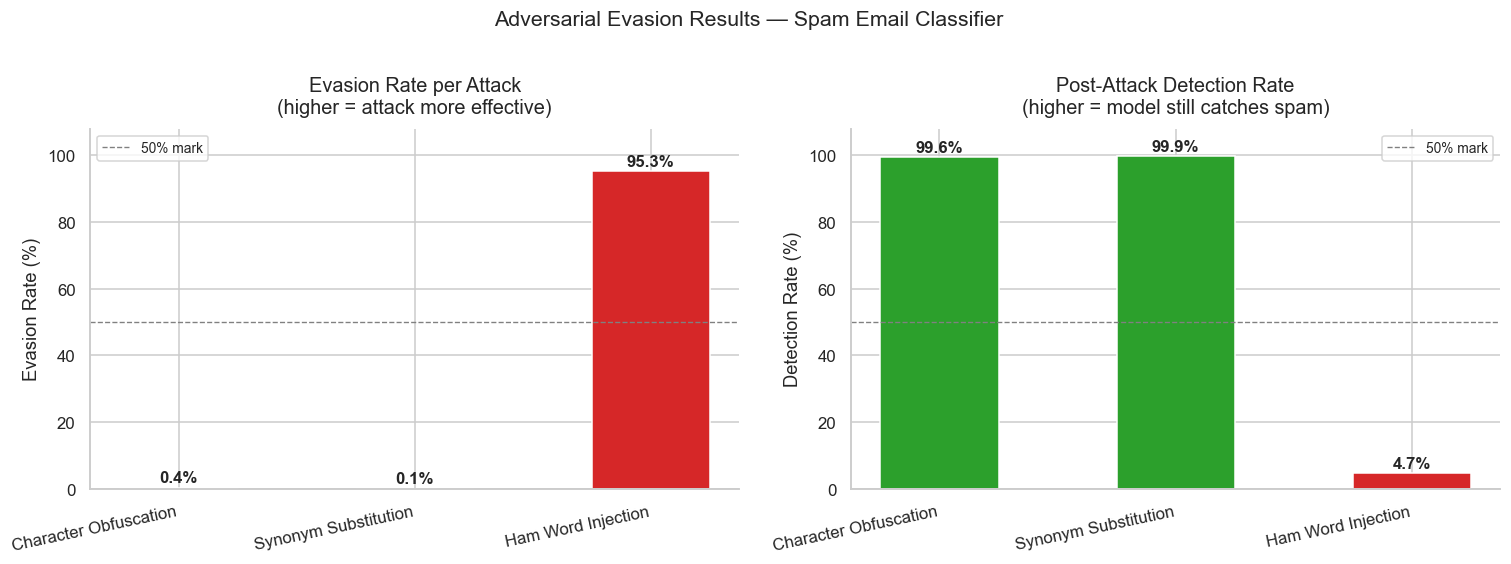

In [10]:
# ── Prepare data for charts ───────────────────────────────────────────────────
# Strip the leading '1. ' / '2. ' / '3. ' from attack names for cleaner labels
short_labels    = [ATTACK_NAMES[k].split('. ', 1)[1] for k in results]
evasion_rates   = [results[k]['evasion_rate'] * 100 for k in results]
detection_rates = [results[k]['post_attack_detection'] * 100 for k in results]


def bar_color(rate, invert=False):
    """Color-code a percentage: red >= 50%, orange 20-49%, green < 20%.
    Set invert=True when high rate is *good* (e.g. detection rate)."""
    effective = (100 - rate) if invert else rate
    if effective >= 50: return '#d62728'   # red   — bad for the defender
    if effective >= 20: return '#ff7f0e'   # orange
    return '#2ca02c'                       # green — good for the defender


evasion_colors   = [bar_color(r) for r in evasion_rates]
detection_colors = [bar_color(r, invert=True) for r in detection_rates]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Evasion Rate ─────────────────────────────────────────────────────
bars1 = ax1.bar(short_labels, evasion_rates, color=evasion_colors, width=0.5, edgecolor='white')
ax1.set_title('Evasion Rate per Attack\n(higher = attack more effective)', fontsize=13, pad=10)
ax1.set_ylabel('Evasion Rate (%)')
ax1.set_ylim(0, 108)
ax1.axhline(50, color='grey', linestyle='--', linewidth=0.9, label='50% mark')
ax1.legend(fontsize=9)
for bar, val in zip(bars1, evasion_rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
ax1.set_xticklabels(short_labels, rotation=12, ha='right')

# ── Chart 2: Post-Attack Detection Rate ──────────────────────────────────────
bars2 = ax2.bar(short_labels, detection_rates, color=detection_colors, width=0.5, edgecolor='white')
ax2.set_title('Post-Attack Detection Rate\n(higher = model still catches spam)', fontsize=13, pad=10)
ax2.set_ylabel('Detection Rate (%)')
ax2.set_ylim(0, 108)
ax2.axhline(50, color='grey', linestyle='--', linewidth=0.9, label='50% mark')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, detection_rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
ax2.set_xticklabels(short_labels, rotation=12, ha='right')

sns.despine()
plt.suptitle('Adversarial Evasion Results — Spam Email Classifier', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5 — Takeaway

### Why Ham Injection Dominates

Ham word injection typically achieves the highest evasion rate because it attacks the model's **score aggregation** rather than individual tokens.

TF-IDF represents a document as a weighted sum over all its tokens. By appending ~400 words of corporate vocabulary — each carrying a near-zero or negative LR coefficient — the overall score is dragged below the decision boundary, even though every original spam word is still present and still recognised. The arithmetic is simple:

> (a few strong spam signals) + (many weak ham signals) → net score: *ham*

### Why Character Obfuscation and Synonym Substitution Were Weaker

Both attacks neutralise only the tokens they can explicitly target:

- **Character obfuscation** only affects words in our top-50 spam-word list that actually appear in the email. If the email's strongest signals come from words *outside* that list, they survive unchanged and keep the score high.

- **Synonym substitution** is bounded by the 50-word hardcoded dictionary in `attack.py`. Many high-weight spam tokens have no entry in the map, so they pass through intact.

In both cases the attack neutralises *some* evidence — but not enough to cross the decision boundary for a high-confidence spam prediction.

### Defences That Would Work

| Defence | Why it helps |
|---------|-------------|
| **Character normalisation** | Convert `€→e`, `0→o`, `$→s` before tokenising — kills obfuscation instantly |
| **Semantic embeddings (BERT)** | Represent meaning, not spelling; `free` and `complimentary` land near each other in vector space |
| **Adversarial training** | Include attacked emails in the training set so the model learns the attack patterns |
| **Injection / length detection** | Flag emails with abnormally long bodies or mismatched vocabulary tone |
| **Ensemble models** | Combine TF-IDF with character n-grams, URL features, and sender reputation |

### Real-World Relevance

Spam filters are one of the oldest adversarial systems in computing. Every technique shown here — obfuscation, paraphrasing, content stuffing — has been deployed by real spammers since the early 2000s. Understanding *why* bag-of-words models fail under these mutations is the first step toward building classifiers that don't.